# Figure 6 — Unsupervised clustering recovers distinct behavioral states from observable choice metrics
Source: `_source_archive/by_figure/Fig6/07b_KMEANS_Final.ipynb`. Target
label: `classify_state_v3` (4-state: Engaged/Exploration/Left Bias/Right
Bias, displayed as "Exploitation" for Engaged per the manuscript's own
panel labels -- see config.yaml's `state_taxonomy.display_labels`).

**This notebook was rebuilt after cross-checking against the actual
submitted manuscript PDF** (`2026.06.30.734629v1.full (4).pdf`, Figure 6
legend). The previous version of this notebook ported the source
notebook's own internal "PUBLICATION FIGURE" plotting cells directly, on
the assumption those cells corresponded 1:1 to the manuscript's real Fig 6
panels. They did not:
- the source's K-Means figure bundled silhouette/BIC/AIC model-selection
  curves and a K-Means cluster-mean heatmap together with the PCA
  scatter -- those two belong to **Supp Fig 4's real panels a/b**, not
  Fig 6, and have been moved there.
- the source's 5-panel HMM figure's panel A was an example session traced
  by **HMM** state, and its panel E was **per-animal** occupancy -- neither
  matches Fig 6's real panel a (a **K-means**-colored example session) or
  panel c (occupancy **per state**, averaged across animals, with
  individual **animal** dots -- not a per-animal grouped bar). Its
  transition-matrix/emission-means/dwell-time panels were also split:
  transition matrix and dwell time are kept here as Fig 6's real panels
  d/e; the emission-means heatmap alone moved to **Supp Fig 4's real
  panel c**.
- Fig 6's real panel c (occupancy per state) and panel f (win-stay/
  lose-switch by state) were not built by the source notebook's cells at
  all -- both are new computation here (see
  `src/behavior_metrics/state_clustering.py::state_occupancy_by_animal`
  and `src/behavior_metrics/wsls.py::win_stay_lose_switch_by_state_session`).

See `src/plotting/state_taxonomy.py`'s module docstring for the full
before/after mapping, and `_source_archive/INDEX.md`'s Fig 6 row.

Fixes two REVIEWER_AUDIT.md-documented defects along the way (see
`src/features/state_features.py` and
`src/behavior_metrics/state_clustering.py` docstrings): the duplicated
Abs_Deviation/Choice_Deviation feature, and the resulting K-Means/HMM
feature-set inconsistency. ARI is recomputed from scratch rather than
quoting the source notebook's own header comment ("K-Means ARI=0.58, HMM
ARI=0.62"), which REVIEWER_AUDIT.md found does not match what that
notebook's own executed cells actually produce.

In [1]:
import os
import sys
import json
import functools

sys.path.insert(0, os.path.abspath(".."))

import numpy as np
from IPython.display import SVG, display

from src.io.load_snapshots import load_config, load_snapshot
from src.features import state_features
from src.behavior_metrics import state_classifier, state_clustering, wsls
from src.plotting.style import apply_style
from src.plotting import state_taxonomy as plotting

config = load_config()
apply_style(config)
cfg = config["state_taxonomy"]
STATE_COLORS = config["plotting"]["state_colors"]
DISPLAY_LABELS = cfg["display_labels"]
CLASSES_V3 = ["Engaged", "Exploration", "Left Bias", "Right Bias"]

FIG_DIR = os.path.join("..", config["paths"]["figures_out"], "Fig6")
os.makedirs(FIG_DIR, exist_ok=True)
MANIFEST_DIR = os.path.join("..", config["paths"]["values_manifests_out"])
os.makedirs(MANIFEST_DIR, exist_ok=True)

manifest = {"_stage": "Fig 6 -- K-Means (K=4) + HMM (K=3) clustering, matched to the manuscript's real panels a-f"}


def show(path):
    display(SVG(path))

## Reconstruct state features and apply `classify_state_v3`

In [2]:
df_raw = load_snapshot(config, cfg["input_files"]["reversal_80_20_2abt"])
df = state_features.build_state_features_df(df_raw, cfg["task_type"], cfg["prob_condition"], cfg["rolling_window"])
print(f"{len(df):,} trials, {df['Session_ID'].nunique()} sessions, {df['Animal_Name'].nunique()} animals")
manifest["n_trials"] = int(len(df))
manifest["n_sessions"] = int(df["Session_ID"].nunique())
manifest["n_animals"] = int(df["Animal_Name"].nunique())

/Users/kevinmastro/Documents/Github/marmoset_decision_making/Final_Paper_Pipeline/src/features/state_features.py:91: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  session_sides = df_filtered.groupby("Session_ID").apply(


36,673 trials, 100 sessions, 5 animals


In [3]:
classify_v3 = functools.partial(state_classifier.classify_state_v3, config=cfg["classify_v3"])
df["Behavioral_State_v3"] = df.apply(classify_v3, axis=1)
df["States_Merged_v3"] = df["Behavioral_State_v3"].replace({"Left Bias": "Bias", "Right Bias": "Bias"})
print(df["Behavioral_State_v3"].value_counts())
manifest["state_v3_distribution"] = df["Behavioral_State_v3"].value_counts().to_dict()

train_sessions, test_sessions = state_clustering.train_test_split_sessions(
    df, cfg["train_test_split"]["test_size"], cfg["train_test_split"]["seed"]
)

Behavioral_State_v3
Engaged        17367
Exploration    11653
Left Bias       3736
Right Bias      3717
Unknown          200
Name: count, dtype: int64


## K-Means (K=4) fit + Gaussian-HMM (K=3) fit
Both fits (and their held-out-test ARI) are computed once here and reused
by panels a/b/d/e/f below -- panel c and f additionally use the FULL
(train+test) dataset, since `classify_state_v3` is a fixed, deterministic
rule (not a fit model), so its own occupancy/win-stay/lose-switch
statistics are descriptive, not part of the K-Means/HMM train/test
validation exercise (only the recovery of these labels by K-Means/HMM
needs the held-out split).

In [4]:
kmeans_result = state_clustering.run_kmeans_validation(
    df, "Behavioral_State_v3", CLASSES_V3,
    cfg["features"], train_sessions, test_sessions,
    cfg["kmeans"]["k_range"], cfg["kmeans"]["k_best"], cfg["train_test_split"]["seed"],
    config["state_taxonomy"]["pca_n_components"], config["state_taxonomy"]["pca_plot_subsample_per_session"],
)
print(f"K-Means ARI: train={kmeans_result['ari_train']:.3f}, test={kmeans_result['ari_test']:.3f} "
      f"(K-Means fit at K={kmeans_result['k_used']}, matching Fig 6's reported K=4)")
manifest["kmeans"] = {k: v for k, v in kmeans_result.items() if k not in ("pca_df_plot", "df_test_classified")}

K-Means ARI: train=0.848, test=0.851 (K-Means fit at K=4, matching Fig 6's reported K=4)


/Users/kevinmastro/Documents/Github/marmoset_decision_making/Final_Paper_Pipeline/src/behavior_metrics/state_clustering.py:120: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), pca_subsample_per_session), random_state=seed))


In [5]:
hmm_result = state_clustering.run_hmm_validation(
    df, "States_Merged_v3", "Behavioral_State_v3", cfg["features"], train_sessions, test_sessions,
    cfg["hmm"]["n_states"], cfg["hmm"]["n_trials_drop"], cfg["hmm"]["n_restarts"], cfg["train_test_split"]["seed"],
)
CLASSES_3 = hmm_result["classes_3"]
print(f"HMM ARI: train(3-state)={hmm_result['ari_train_3state']:.3f}, "
      f"test(3-state)={hmm_result['ari_test_3state']:.3f}")
manifest["hmm"] = {k: v for k, v in hmm_result.items() if k != "df_test_classified"}

HMM ARI: train(3-state)=0.457, test(3-state)=0.472


## Panel a
**Manuscript legend:** *"Representative sessions from a single animal
(Knuckles) showing block structure (top), rewarded and unrewarded choices
and rolling accuracy computed over a five-trial window (middle), and
trial-by-trial K-means state classification (bottom). Colors correspond
to the four states defined in the legend."*

Rebuilt from this legend: the previous version of this panel showed an
**HMM**-state-colored example session (from the notebook's old 5-panel
HMM figure), not a **K-means**-state-colored one, and did not restrict to
animal Knuckles specifically. Uses
`state_clustering.build_example_session` on the K-Means result's own
`df_test_classified` (this trial's `KMeans_State` assignment, not
`Behavioral_State_v3` directly, since the panel is specifically about the
K-means classification recovering the state), restricted to Knuckles'
own longest held-out test session (a documented judgment call, matching
the same "longest session" convention already used elsewhere in this
pipeline for example-session panels -- the manuscript does not state an
exact selection rule beyond naming the animal).

Panel a example session: 2023-09-28_20230928_Knuckles_Reversal3.1 (510 trials, animal=Knuckles)


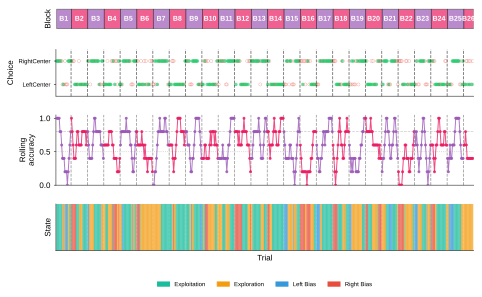

In [6]:
df_ex, example_session_id = state_clustering.build_example_session(
    kmeans_result["df_test_classified"], animal_col="Animal_Name", animal_name="Knuckles"
)
print(f"Panel a example session: {example_session_id} ({len(df_ex)} trials, animal=Knuckles)")
manifest["panel_a_example_session"] = {"session_id": str(example_session_id), "n_trials": int(len(df_ex))}

plotting.plot_kmeans_example_session(
    df_ex, STATE_COLORS, DISPLAY_LABELS, CLASSES_V3, os.path.join(FIG_DIR, "panel_a_example_session.svg")
)
show(os.path.join(FIG_DIR, "panel_a_example_session.svg"))

## Panel b
**Manuscript legend:** *"Principal component projections of the
behavioral feature space colored by K-Means cluster identity. Left: PC1
(37.9% variance) versus PC2 (28.1% variance). PC1 separates Exploit from
Exploration and Bias states along a performance axis; PC2 separates Bias
from Exploration within the low-PC1 region. Right: PC1 versus PC3 (25.0%
variance). PC3 separates left from right spatial bias along a
lateralization axis. Small Gaussian jitter (σ=0.03) added for
visualization. Colors indicate cluster identity (Exploit: teal;
Exploration: orange; Left Bias: blue; Right Bias: red)."*

Rebuilt as a standalone 2-panel scatter (previously bundled into the same
mega-figure as the silhouette/BIC/AIC curves and cluster-mean heatmap,
which belong to Supp Fig 4 instead -- see below).

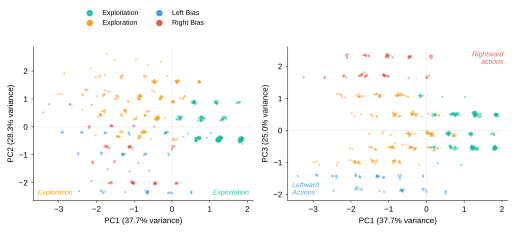

PCA explained variance (PC1-PC3): ['37.7%', '28.3%', '25.0%']


In [7]:
plotting.plot_kmeans_pca_scatter(
    kmeans_result, CLASSES_V3, STATE_COLORS, DISPLAY_LABELS, os.path.join(FIG_DIR, "panel_b_pca_scatter.svg")
)
show(os.path.join(FIG_DIR, "panel_b_pca_scatter.svg"))
print(f"PCA explained variance (PC1-PC3): {[f'{v * 100:.1f}%' for v in kmeans_result['pca_explained_variance']]}")

## Panel c
**Manuscript legend:** *"State occupancy (% of trials) per behavioral
state. Bars indicate the mean across animals; dots indicate individual
animal means (n=5)."*

**Not built in the previous version of this notebook** (which instead had
a per-animal GROUPED-bar "occupancy per animal" panel as part of the old
HMM mega-figure -- a different statistic). Built here directly from the
legend: per-animal occupancy fractions of `Behavioral_State_v3` (excluding
the small `Unknown` fraction, ~0.5% of trials, from the denominator -- a
documented judgment call, since `Unknown` is not one of the four states
being reported on) over the FULL dataset (train+test), then a bar (mean
across animals) + dot (each animal's own mean) per state. Reuses
`state_clustering.state_occupancy_by_animal` (already generic over which
state column/class list it's given) rather than a new function.

                  mean       sem
State                           
Engaged      48.055777  1.454934
Exploration  30.417849  2.508991
Left Bias    10.551530  2.438455
Right Bias   10.974844  2.262281


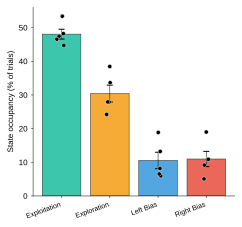

In [8]:
df_known = df[df["Behavioral_State_v3"] != "Unknown"].copy()
occ_df = state_clustering.state_occupancy_by_animal(df_known, CLASSES_V3, state_col="Behavioral_State_v3")
print(occ_df.groupby("State")["Occupancy"].agg(["mean", "sem"]).reindex(CLASSES_V3))
manifest["panel_c_state_occupancy"] = {
    "by_animal": occ_df.pivot(index="Animal", columns="State", values="Occupancy").to_dict(orient="index"),
    "mean_across_animals": occ_df.groupby("State")["Occupancy"].mean().reindex(CLASSES_V3).to_dict(),
    "sem_across_animals": occ_df.groupby("State")["Occupancy"].sem().reindex(CLASSES_V3).to_dict(),
}

plotting.plot_state_occupancy_bar(
    occ_df, CLASSES_V3, STATE_COLORS, DISPLAY_LABELS, os.path.join(FIG_DIR, "panel_c_state_occupancy.svg"),
    seed=config["random_seed"],
)
show(os.path.join(FIG_DIR, "panel_c_state_occupancy.svg"))

## Panel d
**Manuscript legend:** *"Transition probability matrix from a Gaussian
Hidden Markov Model fit to behavioral features. Row-normalized to give
the conditional probability of transitioning from each state (rows) to
each state (columns). Direct transitions from Bias to Exploitation were
almost never observed (p=0.007)."*

## Panel e
**Manuscript legend:** *"Mean dwell time per HMM state, derived
analytically from self-transition probabilities."*

Panels d and e were already correctly built in the previous version of
this notebook (as two of the five panels in the old HMM mega-figure) --
kept here, just split out from that figure's other two panels (an
HMM-colored example session and per-animal occupancy) which did not
belong in Fig 6 at all (see panel a/c above) or in this figure (emission
means moved to Supp Fig 4's real panel c).

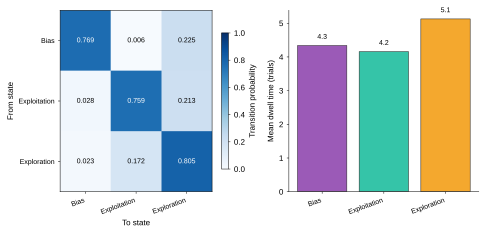

Transition matrix:
{'Bias': {'Bias': 0.7695, 'Engaged': 0.006, 'Exploration': 0.2245}, 'Engaged': {'Bias': 0.0279, 'Engaged': 0.7594, 'Exploration': 0.2127}, 'Exploration': {'Bias': 0.0232, 'Engaged': 0.1718, 'Exploration': 0.805}}
Mean dwell time (trials): {'Bias': 4.337528165930686, 'Engaged': 4.1561738921859455, 'Exploration': 5.127961857128593}


In [9]:
plotting.plot_hmm_transition_and_dwell(
    hmm_result, CLASSES_3, STATE_COLORS, DISPLAY_LABELS, os.path.join(FIG_DIR, "panels_de_transition_dwell.svg")
)
show(os.path.join(FIG_DIR, "panels_de_transition_dwell.svg"))
print("Transition matrix:")
print(hmm_result["transition_matrix"])
print("Mean dwell time (trials):", hmm_result["mean_dwell_trials"])

## Panel f
**Manuscript legend:** *"Win-stay versus lose-switch probability for
Exploitation and Exploration trials. Each point represents one session
colored by rolling accuracy within state (Exploitation: teal-to-purple;
Exploration: orange-to-purple). Circles indicate Exploitation trials;
squares indicate Exploration trials."*

**Not built in the previous version of this notebook.** New computation:
`wsls.win_stay_lose_switch_by_state_session` restricts the existing
pooled win-stay/lose-shift logic (already used for Fig 2/3) to trials
whose OWN `Behavioral_State_v3` is Engaged ("Exploitation") or
Exploration, one row per (session, state) pair, over the FULL dataset
(same "classify_state_v3 is descriptive, not part of the K-Means/HMM
train/test validation" reasoning as panel c). A minimum-trial floor
(`state_taxonomy.wsls_min_trials_per_state_session` = 5, see config.yaml)
drops (session, state) pairs too small to give a stable estimate -- a
judgment call, not tuned to any manuscript number.

             win_stay                 lose_switch                  \
                 mean       sem count        mean       sem count   
state                                                               
Engaged      0.956242  0.003115   100    0.128832  0.012085   100   
Exploration  0.800258  0.008704   100    0.491366  0.010520   100   

            rolling_accuracy_in_state                  
                                 mean       sem count  
state                                                  
Engaged                      0.782518  0.002540   100  
Exploration                  0.448351  0.005714   100  


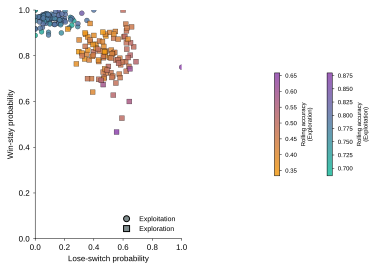

In [10]:
wsls_state_df = wsls.win_stay_lose_switch_by_state_session(
    df, "Behavioral_State_v3", cfg["wsls_states"], cfg["wsls_min_trials_per_state_session"],
)
print(wsls_state_df.groupby("state")[["win_stay", "lose_switch", "rolling_accuracy_in_state"]].agg(["mean", "sem", "count"]))
manifest["panel_f_wsls_by_state"] = {
    state: {
        "win_stay_mean": float(sdf["win_stay"].mean()),
        "win_stay_sem": float(sdf["win_stay"].sem()),
        "lose_switch_mean": float(sdf["lose_switch"].mean()),
        "lose_switch_sem": float(sdf["lose_switch"].sem()),
        "n_session_state_rows": int(len(sdf)),
    }
    for state, sdf in wsls_state_df.groupby("state")
}

plotting.plot_wsls_state_scatter(wsls_state_df, DISPLAY_LABELS, os.path.join(FIG_DIR, "panel_f_wsls_scatter.svg"))
show(os.path.join(FIG_DIR, "panel_f_wsls_scatter.svg"))

## Values manifest

In [11]:
manifest_path = os.path.join(MANIFEST_DIR, "Fig6.json")
with open(manifest_path, "w") as f:
    json.dump(manifest, f, indent=2, default=str)
print(f"\nSaved values manifest: {manifest_path}")
print(json.dumps(
    {k: v for k, v in manifest.items() if k not in ("kmeans", "hmm", "panel_c_state_occupancy", "panel_f_wsls_by_state")},
    indent=2, default=str,
))


Saved values manifest: ../outputs/values_manifests/Fig6.json
{
  "_stage": "Fig 6 -- K-Means (K=4) + HMM (K=3) clustering, matched to the manuscript's real panels a-f",
  "n_trials": 36673,
  "n_sessions": 100,
  "n_animals": 5,
  "state_v3_distribution": {
    "Engaged": 17367,
    "Exploration": 11653,
    "Left Bias": 3736,
    "Right Bias": 3717,
    "Unknown": 200
  },
  "panel_a_example_session": {
    "session_id": "2023-09-28_20230928_Knuckles_Reversal3.1",
    "n_trials": 510
  }
}
